
# FEL Results Visualizer

This notebook helps you explore the results produced by your FEL sweeps.

**What you can do:**
- Load the summary CSV created by `analyze_logs.py`.
- Plot Macro‑F1 vs labels curves for runs under a chosen study folder.
- Inspect runtime breakdown and per‑class coverage.
- Compute AULC over a label window.


In [1]:

# ==== CONFIG: set these to your repo paths ====
RUNS_ROOT = "runs/fel_sweeps"      # root folder containing study subfolders (1_overall, 2_micro, ...)
SUMMARY_CSV = "runs/fel_sweeps_summary.csv"   # CSV from analyze_logs.py
AUC_WINDOW = (0, 18000)            # (start_labels, end_labels)

# If you're running this notebook outside the repo root, set absolute paths above.


In [2]:

# Imports
import os, json, glob, csv, math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper: robust JSONL reader (pick the largest .jsonl in a folder)
def read_jsonl_best(path):
    cand = sorted(glob.glob(os.path.join(path, "*.jsonl")))
    if not cand:
        cand = glob.glob(os.path.join(path, "**", "*.jsonl"), recursive=True)
        if not cand:
            return []
    best = max(cand, key=lambda p: os.path.getsize(p))
    rows = []
    with open(best, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return rows

def labels_after_round(seed_k, r_index, batch_B):
    return seed_k + r_index * batch_B

def auc_trapz(xs, ys):
    if len(xs) < 2: 
        return 0.0
    area = 0.0
    for i in range(1, len(xs)):
        dx = xs[i] - xs[i-1]
        area += dx * 0.5 * (ys[i] + ys[i-1])
    return area


## Load summary CSV

In [5]:

# Load and show the summary table
if not Path(SUMMARY_CSV).exists():
    print(f"Summary CSV not found at {SUMMARY_CSV}. Run analyze_logs.py first.")
else:
    df = pd.read_csv(SUMMARY_CSV)
    # from caas_jupyter_tools import display_dataframe_to_user
    # display_dataframe_to_user("FEL Sweep Summary", df)
    # display(df.head(10))
df

,run,path,points,AULC_0_18000,time_train_s,time_meta_s,time_eval_s,time_acquire_s,cov_L1/L2,cov_L2/L3,cov_L3/L4,cov_L4/L5,cov_L5/S1
0,study3_qbc_ne300_mfsqrt_K5_seed200_B100_R50,runs/fel_sweeps/3_committee/study3_qbc_ne300_m...,0,0.0,783.51,0.0,137.68,188.56,906,1130,974,1206,784
1,study3_qbc_ne500_mfsqrt_K5_seed200_B100_R50,runs/fel_sweeps/3_committee/study3_qbc_ne500_m...,0,0.0,1309.23,0.0,222.82,269.86,920,1122,986,1188,784
2,study3_qbc_ne500_mflog2_K5_seed200_B100_R50,runs/fel_sweeps/3_committee/study3_qbc_ne500_m...,0,0.0,697.53,0.0,220.90,268.40,929,1119,986,1183,783
3,study3_qbc_ne100_mflog2_K5_seed200_B100_R50,runs/fel_sweeps/3_committee/study3_qbc_ne100_m...,0,0.0,153.61,0.0,56.27,111.66,934,1083,998,1192,793
4,study3_qbc_ne100_mfsqrt_K5_seed200_B100_R50,runs/fel_sweeps/3_committee/study3_qbc_ne100_m...,0,0.0,277.70,0.0,57.11,113.74,910,1134,973,1195,788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,study2_seed25_add500_B50_K5_ttatta3,runs/fel_sweeps/2_micro/study2_seed25_add500_B...,0,0.0,5.72,0.0,11.33,9.57,97,100,88,125,90
99,study2_seed50_add500_B50_K0_ttatta3,runs/fel_sweeps/2_micro/study2_seed50_add500_B...,0,0.0,3.31,0.0,10.83,9.18,106,116,107,100,71
100,study2_seed100_add250_B50_K0_ttatta3,runs/fel_sweeps/2_micro/study2_seed100_add250_...,0,0.0,1.65,0.0,5.47,4.41,61,70,42,48,29
101,study2_seed100_add500_B50_K10_ttatta3,runs/fel_sweeps/2_micro/study2_seed100_add500_...,0,0.0,7.19,0.0,11.39,10.00,115,101,95,109,80


## Select a study folder to visualize Macro‑F1 vs labels

In [6]:

# Choose a study subfolder under RUNS_ROOT (e.g., '1_overall', '2_micro', '3_committee', '4_noniid', '5_extras')
STUDY_FOLDER = "1_overall"   # <-- change this to the study you want to inspect

study_path = Path(RUNS_ROOT) / STUDY_FOLDER
if not study_path.exists():
    print(f"Study path not found: {study_path}")
else:
    run_dirs = [p for p in study_path.glob("**/") if (p / "derived_").exists() or list(p.glob("*.yaml"))]
    # fallback: any leaf with a jsonl
    if not run_dirs:
        run_dirs = [p for p in study_path.glob("**/") if list(p.glob("*.jsonl"))]
    print(f"Found {len(run_dirs)} candidate run folders under {study_path}")


Found 8 candidate run folders under runs/fel_sweeps/1_overall


## Build Macro‑F1 curves for each run

In [7]:

def extract_curve_from_logs(run_dir):
    logs = read_jsonl_best(str(run_dir))
    if not logs:
        return None
    seed_k = None
    batch_B = None
    xs, ys = [], []
    for i, rec in enumerate(logs, start=1):
        if batch_B is None:
            batch_B = rec.get("al", {}).get("batch_B") or rec.get("al_batch_B")
        if seed_k is None:
            seed_k = rec.get("seed_k")
        macro = None
        # prefer META if present
        for key in ("meta","rf"):
            if key in rec.get("metrics", {}):
                m = rec["metrics"][key]
                macro = m.get("f1_macro") or m.get("macro_f1") or macro
        if macro is None:
            macro = rec.get("metrics_rest", {}).get("f1_macro")
        # infer batch_B if still missing
        if batch_B is None:
            cdict = rec.get("picked_per_class") or rec.get("clients", {}).get("RSNA", {}).get("picked_per_class")
            if cdict:
                batch_B = sum(int(v) for v in cdict.values())
        if seed_k is None:
            seed_k = 200
        labels = seed_k + i * (batch_B or 100)
        if macro is not None:
            xs.append(labels)
            ys.append(float(macro))
    return np.array(xs), np.array(ys)

# Build curves
curves = {}
for run_dir in (study_path.glob("*") if study_path.exists() else []):
    if run_dir.is_dir():
        xs_ys = extract_curve_from_logs(run_dir)
        if xs_ys is not None:
            curves[run_dir.name] = xs_ys

print(f"Curves extracted: {len(curves)}")


Curves extracted: 8


## Plot: Macro‑F1 vs labels (all runs in the study)

In [12]:
curves

{'study1_entropy_K0_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_least_confident_K5_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_qbc_K0_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_least_confident_K0_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_margin_K0_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_qbc_K5_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_margin_K5_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64)),
 'study1_entropy_K5_seed200_B200_R60': (array([], dtype=float64),
  array([], dtype=float64))}

/tmp/ipykernel_437078/589326302.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


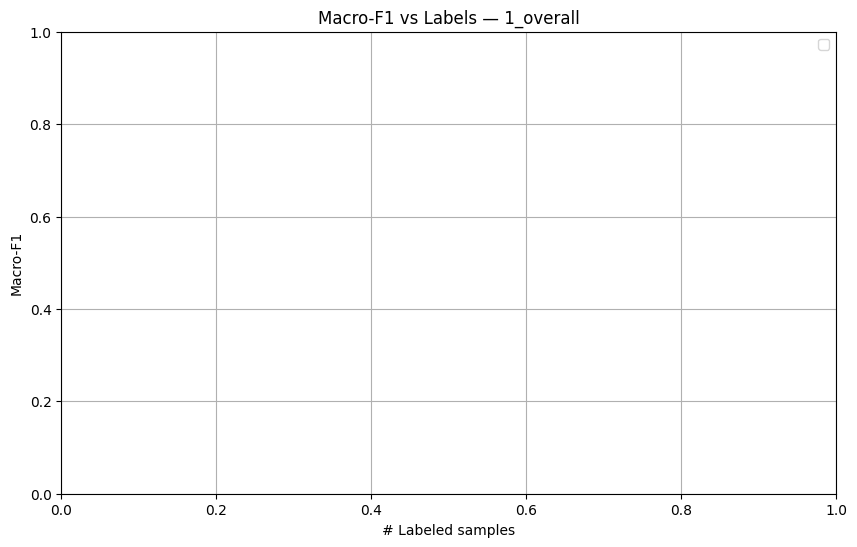

In [8]:

# Plot all curves
plt.figure(figsize=(10,6))
for run_id, (xs, ys) in sorted(curves.items()):
    if len(xs) > 0:
        plt.plot(xs, ys, label=run_id)
plt.xlabel("# Labeled samples")
plt.ylabel("Macro-F1")
plt.title(f"Macro-F1 vs Labels — {STUDY_FOLDER}")
plt.legend(loc="best")
plt.grid(True)
plt.show()


## Compute AULC over a window for each run

In [9]:

w0, w1 = AUC_WINDOW
aulc_by_run = {}
for run_id, (xs, ys) in curves.items():
    mask = (xs >= w0) & (xs <= w1)
    xw, yw = xs[mask], ys[mask]
    aulc_by_run[run_id] = auc_trapz(xw, yw) if len(xw) >= 2 else 0.0

# Show a small table of AULC (top 10)
aulc_df = pd.DataFrame({"run": list(aulc_by_run.keys()), "AULC": list(aulc_by_run.values())})
aulc_df = aulc_df.sort_values("AULC", ascending=False).head(10).reset_index(drop=True)
display(aulc_df)


,run,AULC
0,study1_entropy_K0_seed200_B200_R60,0.0
1,study1_least_confident_K5_seed200_B200_R60,0.0
2,study1_qbc_K0_seed200_B200_R60,0.0
3,study1_least_confident_K0_seed200_B200_R60,0.0
4,study1_margin_K0_seed200_B200_R60,0.0
5,study1_qbc_K5_seed200_B200_R60,0.0
6,study1_margin_K5_seed200_B200_R60,0.0
7,study1_entropy_K5_seed200_B200_R60,0.0


## Plot: Runtime breakdown per run (stacked bars of totals)

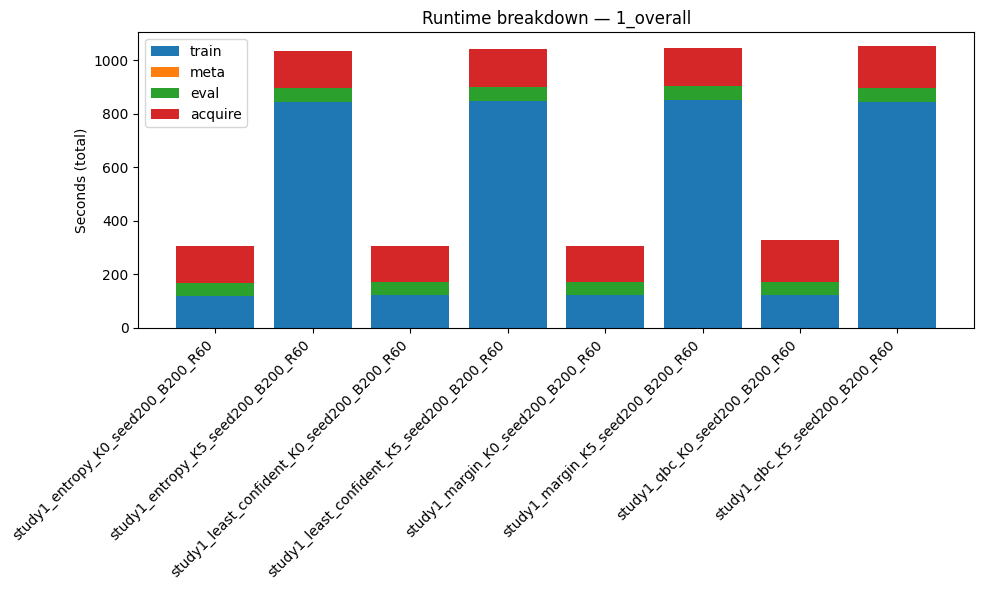

In [10]:

# Pull runtime totals from the summary CSV (if present)
if Path(SUMMARY_CSV).exists():
    sdf = pd.read_csv(SUMMARY_CSV)
    sdf = sdf[sdf["path"].str.contains(str(study_path))] if study_path.exists() else sdf
    # Keep only runs present in curves
    sdf = sdf[sdf["run"].isin(list(curves.keys()))].copy()
    if len(sdf) == 0:
        print("No summary rows for this study in SUMMARY_CSV.")
    else:
        # Select top N by AULC if we computed it
        if 'aulc_df' in globals() and len(aulc_df) > 0:
            top_runs = set(aulc_df["run"].tolist())
            sdf = sdf[sdf["run"].isin(top_runs)]
        sdf = sdf.sort_values("run")

        # Prepare stacked bars
        idx = np.arange(len(sdf))
        train = sdf["time_train_s"].values
        meta = sdf["time_meta_s"].values
        ev   = sdf["time_eval_s"].values
        acq  = sdf["time_acquire_s"].values

        plt.figure(figsize=(10,6))
        plt.bar(idx, train, label="train")
        plt.bar(idx, meta, bottom=train, label="meta")
        plt.bar(idx, ev, bottom=train+meta, label="eval")
        plt.bar(idx, acq, bottom=train+meta+ev, label="acquire")
        plt.xticks(idx, sdf["run"], rotation=45, ha="right")
        plt.ylabel("Seconds (total)")
        plt.title(f"Runtime breakdown — {STUDY_FOLDER}")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()
else:
    print("SUMMARY_CSV not found; skipping runtime plot.")


## Plot: Per-class coverage (total picked over all rounds)

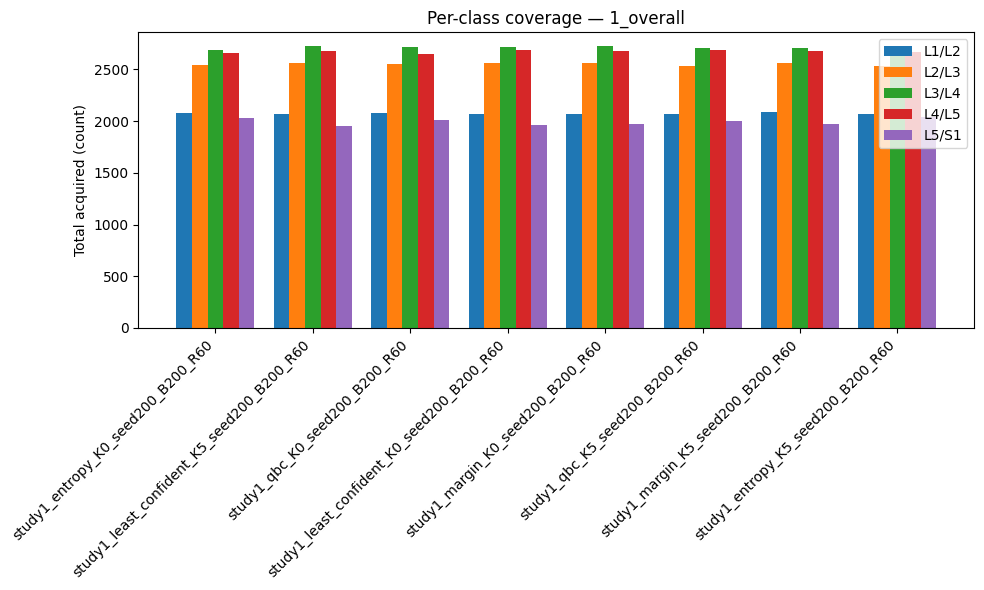

In [11]:

# Use coverage columns from summary CSV if available (cov_<class>)
if Path(SUMMARY_CSV).exists():
    sdf = pd.read_csv(SUMMARY_CSV)
    sdf = sdf[sdf["path"].str.contains(str(study_path))] if study_path.exists() else sdf
    cov_cols = [c for c in sdf.columns if c.startswith("cov_")]
    if len(cov_cols) == 0:
        print("No coverage columns in summary CSV. You may need to log picked_per_class per round.")
    else:
        # Filter to runs we plotted (optional)
        run_filter = set(curves.keys())
        sdf = sdf[sdf["run"].isin(run_filter)]
        # Grouped bars per run
        plt.figure(figsize=(10,6))
        idx = np.arange(len(sdf))
        width = 0.8 / max(1, len(cov_cols))

        for j, col in enumerate(sorted(cov_cols)):
            vals = sdf[col].fillna(0).values
            plt.bar(idx + j*width, vals, width=width, label=col.replace("cov_",""))
        plt.xticks(idx + (len(cov_cols)-1)*width/2, sdf["run"], rotation=45, ha="right")
        plt.ylabel("Total acquired (count)")
        plt.title(f"Per-class coverage — {STUDY_FOLDER}")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()
else:
    print("SUMMARY_CSV not found; skipping coverage plot.")
